<a href="https://colab.research.google.com/github/krishnagaadha9/churn-prediction-project/blob/main/churn_prediction_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost


In [3]:
from google.colab import files
uploaded = files.upload()  # A button will appear — click it and upload BankChurners.csv


Saving BankChurners.csv to BankChurners.csv


In [4]:
# Step 1 — install and load
!pip install jupysql -q

# Step 2 — imports
import pandas as pd
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Step 3 — load CSV
df = pd.read_csv('BankChurners.csv')
df = df.iloc[:, :-2]
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.8/192.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.0/264.0 kB 9.6 MB/s eta 0:00:00
Dataset shape: (10127, 21)
Columns: ['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


In [5]:
%load_ext sql
%sql sqlite://

Connecting to 'sqlite://'

In [6]:
%sql --persist df

Running query in 'sqlite://'

Success! Persisted df to the database.

In [7]:
%%sql
SELECT COUNT(*) as total_rows FROM df

Running query in 'sqlite://'

total_rows
10127


In [8]:
%%sql
SELECT
    COUNT(*) as total_customers,
    SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) as churned,
    SUM(CASE WHEN Attrition_Flag = 'Existing Customer' THEN 1 ELSE 0 END) as retained,
    ROUND(SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate_pct
FROM df

Running query in 'sqlite://'

total_customers,churned,retained,churn_rate_pct
10127,1627,8500,16.07


In [9]:
%%sql
SELECT
    Attrition_Flag,
    ROUND(AVG(Customer_Age), 1) as avg_age,
    ROUND(AVG(Total_Trans_Ct), 1) as avg_transactions,
    ROUND(AVG(Total_Trans_Amt), 1) as avg_amount,
    ROUND(AVG(Months_Inactive_12_mon), 1) as avg_inactive_months,
    ROUND(AVG(Credit_Limit), 1) as avg_credit_limit
FROM df
GROUP BY Attrition_Flag

Running query in 'sqlite://'

Attrition_Flag,avg_age,avg_transactions,avg_amount,avg_inactive_months,avg_credit_limit
Attrited Customer,46.7,44.9,3095.0,2.7,8136.0
Existing Customer,46.3,68.7,4654.7,2.3,8726.9


In [10]:
%%sql
SELECT
    Gender,
    COUNT(*) as total,
    SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) as churned,
    ROUND(SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate_pct
FROM df
GROUP BY Gender
ORDER BY churn_rate_pct DESC

Running query in 'sqlite://'

Gender,total,churned,churn_rate_pct
F,5358,930,17.36
M,4769,697,14.62


In [11]:
%%sql
SELECT
    Education_Level,
    COUNT(*) as total,
    SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) as churned,
    ROUND(SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate_pct
FROM df
GROUP BY Education_Level
ORDER BY churn_rate_pct DESC

Running query in 'sqlite://'

Education_Level,total,churned,churn_rate_pct
Doctorate,451,95,21.06
Post-Graduate,516,92,17.83
Unknown,1519,256,16.85
Uneducated,1487,237,15.94
Graduate,3128,487,15.57
High School,2013,306,15.2
College,1013,154,15.2


In [12]:
%%sql
SELECT
    CASE
        WHEN Customer_Age < 30 THEN 'Under 30'
        WHEN Customer_Age BETWEEN 30 AND 45 THEN '30-45'
        WHEN Customer_Age BETWEEN 46 AND 60 THEN '46-60'
        ELSE 'Over 60'
    END as age_group,
    COUNT(*) as total,
    ROUND(SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate_pct
FROM df
GROUP BY age_group
ORDER BY churn_rate_pct DESC

Running query in 'sqlite://'

age_group,total,churn_rate_pct
46-60,5061,16.62
30-45,4466,15.92
Over 60,405,14.32
Under 30,195,8.72


In [13]:
%%sql
SELECT
    Card_Category,
    COUNT(*) as total,
    SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) as churned,
    ROUND(AVG(Credit_Limit), 2) as avg_credit_limit,
    ROUND(SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate_pct
FROM df
GROUP BY Card_Category
ORDER BY churn_rate_pct DESC

Running query in 'sqlite://'

Card_Category,total,churned,avg_credit_limit,churn_rate_pct
Platinum,20,5,30283.45,25.0
Gold,116,21,28416.37,18.1
Blue,9436,1519,7363.78,16.1
Silver,555,82,25277.84,14.77


In [14]:
# Run this in a Python cell
churned = df[df['Attrition_Flag'] == 'Attrited Customer']
retained = df[df['Attrition_Flag'] == 'Existing Customer']

cols = ['Total_Trans_Ct', 'Months_Inactive_12_mon',
        'Total_Trans_Amt', 'Credit_Limit']

for col in cols:
    print(f"\n--- {col} ---")
    print(f"Churned   | 25th: {churned[col].quantile(0.25):.1f} | "
          f"50th: {churned[col].quantile(0.50):.1f} | "
          f"75th: {churned[col].quantile(0.75):.1f}")
    print(f"Retained  | 25th: {retained[col].quantile(0.25):.1f} | "
          f"50th: {retained[col].quantile(0.50):.1f} | "
          f"75th: {retained[col].quantile(0.75):.1f}")


--- Total_Trans_Ct ---
Churned   | 25th: 37.0 | 50th: 43.0 | 75th: 51.0
Retained  | 25th: 54.0 | 50th: 71.0 | 75th: 82.0

--- Months_Inactive_12_mon ---
Churned   | 25th: 2.0 | 50th: 3.0 | 75th: 3.0
Retained  | 25th: 1.0 | 50th: 2.0 | 75th: 3.0

--- Total_Trans_Amt ---
Churned   | 25th: 1903.5 | 50th: 2329.0 | 75th: 2772.0
Retained  | 25th: 2384.8 | 50th: 4100.0 | 75th: 4781.2

--- Credit_Limit ---
Churned   | 25th: 2114.0 | 50th: 4178.0 | 75th: 9933.5
Retained  | 25th: 2602.0 | 50th: 4643.5 | 75th: 11252.8


In [15]:
%%sql
SELECT
    Customer_Age,
    Gender,
    Card_Category,
    Months_Inactive_12_mon,
    Total_Trans_Ct,
    Total_Trans_Amt,
    Credit_Limit,
    Attrition_Flag
FROM df
WHERE Total_Trans_Ct < 51
AND Total_Trans_Amt < 2772
AND Months_Inactive_12_mon >= 3
ORDER BY Total_Trans_Ct ASC
LIMIT 20

Running query in 'sqlite://'

Customer_Age,Gender,Card_Category,Months_Inactive_12_mon,Total_Trans_Ct,Total_Trans_Amt,Credit_Limit,Attrition_Flag
59,M,Blue,3,10,530,14979.0,Attrited Customer
32,M,Blue,3,10,695,22382.0,Attrited Customer
33,M,Blue,3,10,741,8925.0,Attrited Customer
57,M,Blue,3,11,678,8249.0,Attrited Customer
40,M,Blue,3,11,975,6884.0,Existing Customer
55,F,Blue,4,12,615,2158.0,Attrited Customer
60,F,Blue,4,12,702,1438.3,Attrited Customer
37,M,Blue,3,12,694,3100.0,Attrited Customer
58,M,Blue,4,13,715,1438.3,Attrited Customer
37,M,Blue,3,13,862,6866.0,Attrited Customer


In [16]:
%%sql
SELECT
    CASE
        WHEN Credit_Limit < 5000 THEN 'Low under 5k'
        WHEN Credit_Limit BETWEEN 5000 AND 15000 THEN 'Mid 5k-15k'
        ELSE 'High over 15k'
    END as credit_bucket,
    COUNT(*) as total,
    ROUND(SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate_pct
FROM df
GROUP BY credit_bucket
ORDER BY churn_rate_pct DESC

Running query in 'sqlite://'

credit_bucket,total,churn_rate_pct
Low under 5k,5358,17.28
Mid 5k-15k,2956,15.12
High over 15k,1813,14.01


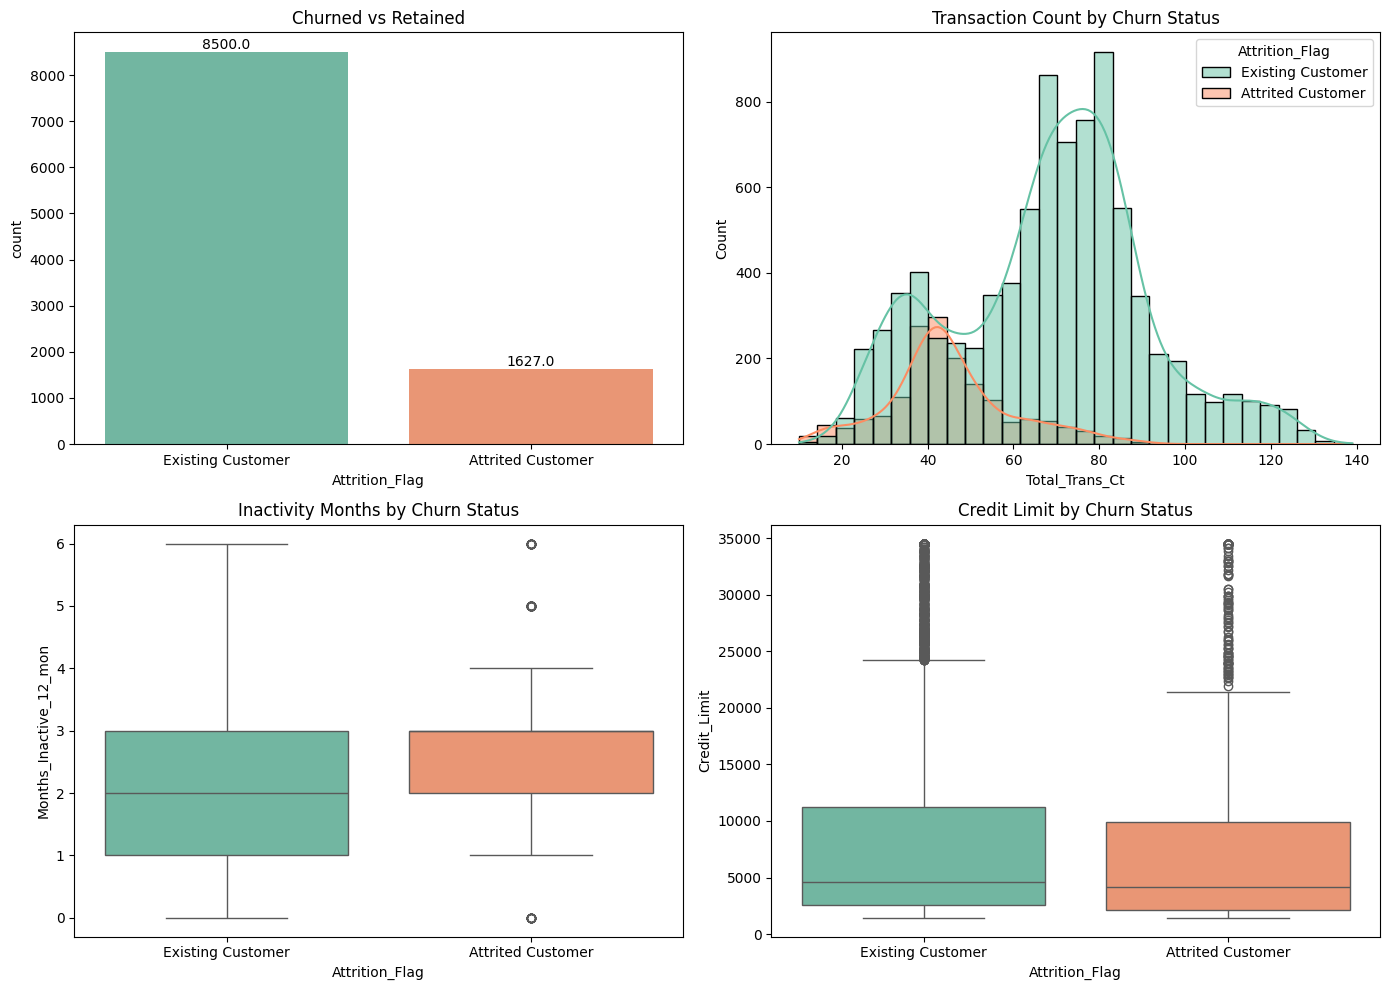

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Churn distribution
sns.countplot(x='Attrition_Flag', data=df,
              palette='Set2', ax=axes[0,0])
axes[0,0].set_title('Churned vs Retained')
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{p.get_height()}',
                       (p.get_x() + p.get_width()/2, p.get_height()),
                       ha='center', va='bottom')

# 2. Transaction count by churn
sns.histplot(data=df, x='Total_Trans_Ct',
             hue='Attrition_Flag', bins=30,
             kde=True, palette='Set2', ax=axes[0,1])
axes[0,1].set_title('Transaction Count by Churn Status')

# 3. Inactivity by churn
sns.boxplot(x='Attrition_Flag', y='Months_Inactive_12_mon',
            data=df, palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Inactivity Months by Churn Status')

# 4. Credit limit by churn
sns.boxplot(x='Attrition_Flag', y='Credit_Limit',
            data=df, palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Credit Limit by Churn Status')

plt.tight_layout()
plt.show()

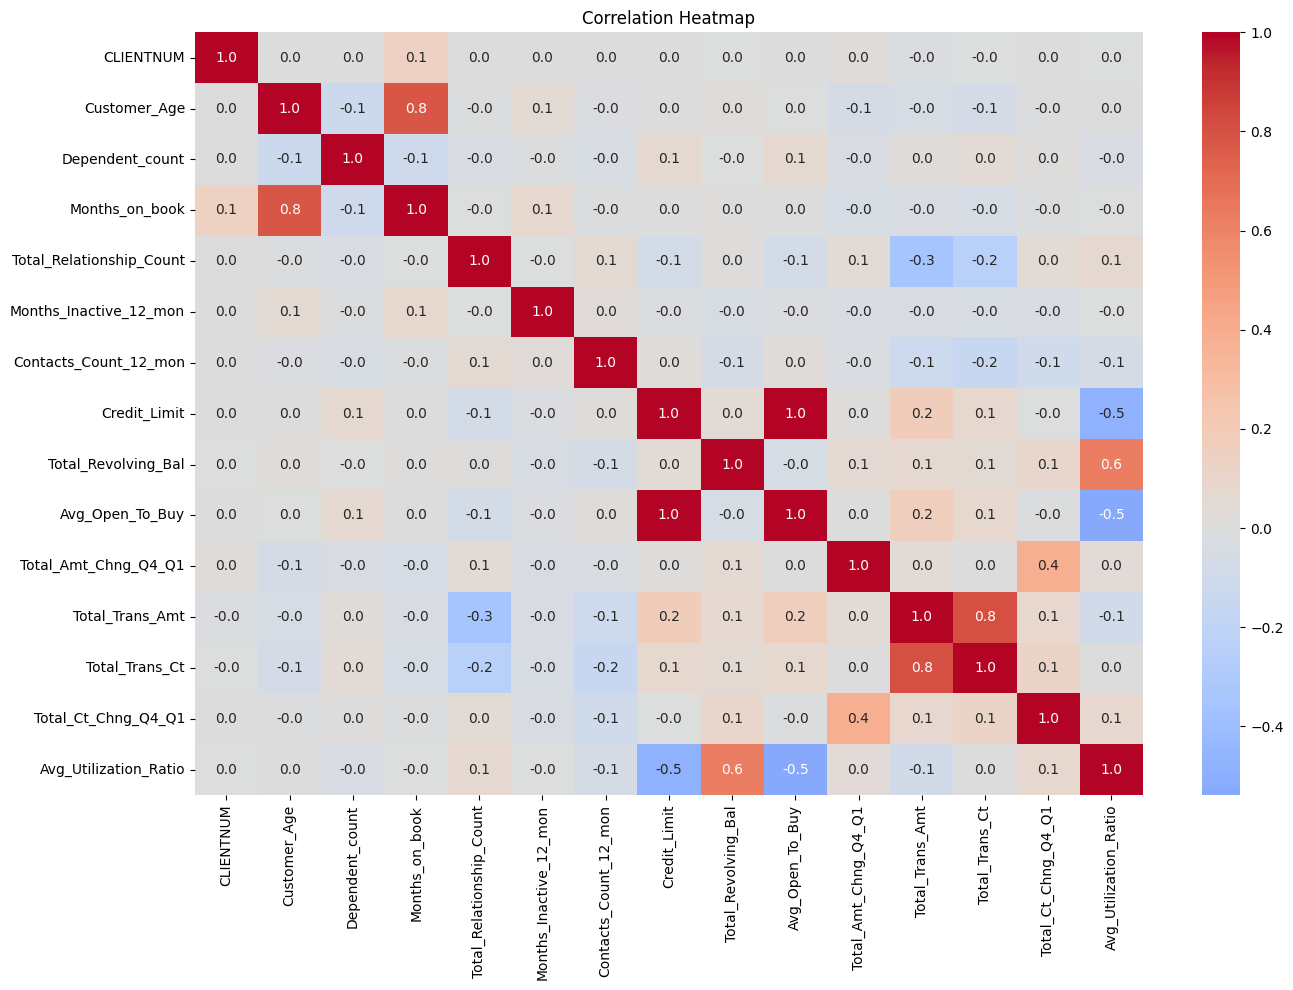

In [18]:
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(),
            annot=True, fmt='.1f',
            cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [19]:
# Convert Attrition_Flag from text to numbers
# Attrited Customer = 1 (churned)
# Existing Customer = 0 (stayed)

df['Attrition_Flag'] = df['Attrition_Flag'].map(
    {'Attrited Customer': 1, 'Existing Customer': 0}
)

print(df['Attrition_Flag'].value_counts())
print("\n0 = Retained, 1 = Churned")

Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64

0 = Retained, 1 = Churned


In [20]:
# CLIENTNUM is just an ID — not useful for prediction
df = df.drop('CLIENTNUM', axis=1)
print("Remaining columns:", df.shape[1])

Remaining columns: 20


In [21]:
from sklearn.preprocessing import LabelEncoder

# Check which columns are text/categorical
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

# Encode each one
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\nAfter encoding:")
df.head()

Categorical columns: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

After encoding:


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,1,3,3,1,2,0,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,0,5,2,2,4,0,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,1,3,2,1,3,0,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,0,4,3,3,4,0,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,1,3,5,1,2,0,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [22]:
# X = everything the model uses to predict (features)
# y = what we're predicting (churned or not)

X = df.drop('Attrition_Flag', axis=1)
y = df['Attrition_Flag']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nChurn distribution in target:")
print(y.value_counts())

Features shape: (10127, 19)
Target shape: (10127,)

Churn distribution in target:
Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42,    # ensures same split every time you run
    stratify=y          # keeps same churn ratio in both splits
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nChurn in training set:", y_train.value_counts().to_dict())
print("Churn in testing set:", y_test.value_counts().to_dict())

Training set size: (8101, 19)
Testing set size: (2026, 19)

Churn in training set: {0: 6799, 1: 1302}
Churn in testing set: {0: 1701, 1: 325}


In [24]:
from imblearn.over_sampling import SMOTE

# SMOTE creates synthetic churned customer examples
# so model sees equal numbers of churned and retained
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())
print("\nTraining set size after SMOTE:", X_train_sm.shape)

Before SMOTE: {0: 6799, 1: 1302}
After SMOTE: {0: 6799, 1: 6799}

Training set size after SMOTE: (13598, 19)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete!")
print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)

Scaling complete!
Training set shape: (13598, 19)
Testing set shape: (2026, 19)


In [26]:
!pip install lightgbm -q

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score)

# Define models — now 4
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

# Train and evaluate each
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train_sm)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {'model': model, 'y_pred': y_pred,
                     'y_prob': y_prob, 'accuracy': acc, 'auc': auc}

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Accuracy : {acc:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print(classification_report(y_test, y_pred,
          target_names=['Retained', 'Churned']))


  Logistic Regression
Accuracy : 0.8554
ROC-AUC  : 0.9053
              precision    recall  f1-score   support

    Retained       0.95      0.88      0.91      1701
     Churned       0.54      0.74      0.62       325

    accuracy                           0.86      2026
   macro avg       0.74      0.81      0.77      2026
weighted avg       0.88      0.86      0.86      2026


  Random Forest
Accuracy : 0.9521
ROC-AUC  : 0.9828
              precision    recall  f1-score   support

    Retained       0.97      0.97      0.97      1701
     Churned       0.85      0.86      0.85       325

    accuracy                           0.95      2026
   macro avg       0.91      0.91      0.91      2026
weighted avg       0.95      0.95      0.95      2026


  XGBoost
Accuracy : 0.9654
ROC-AUC  : 0.9902
              precision    recall  f1-score   support

    Retained       0.98      0.98      0.98      1701
     Churned       0.88      0.90      0.89       325

    accuracy           

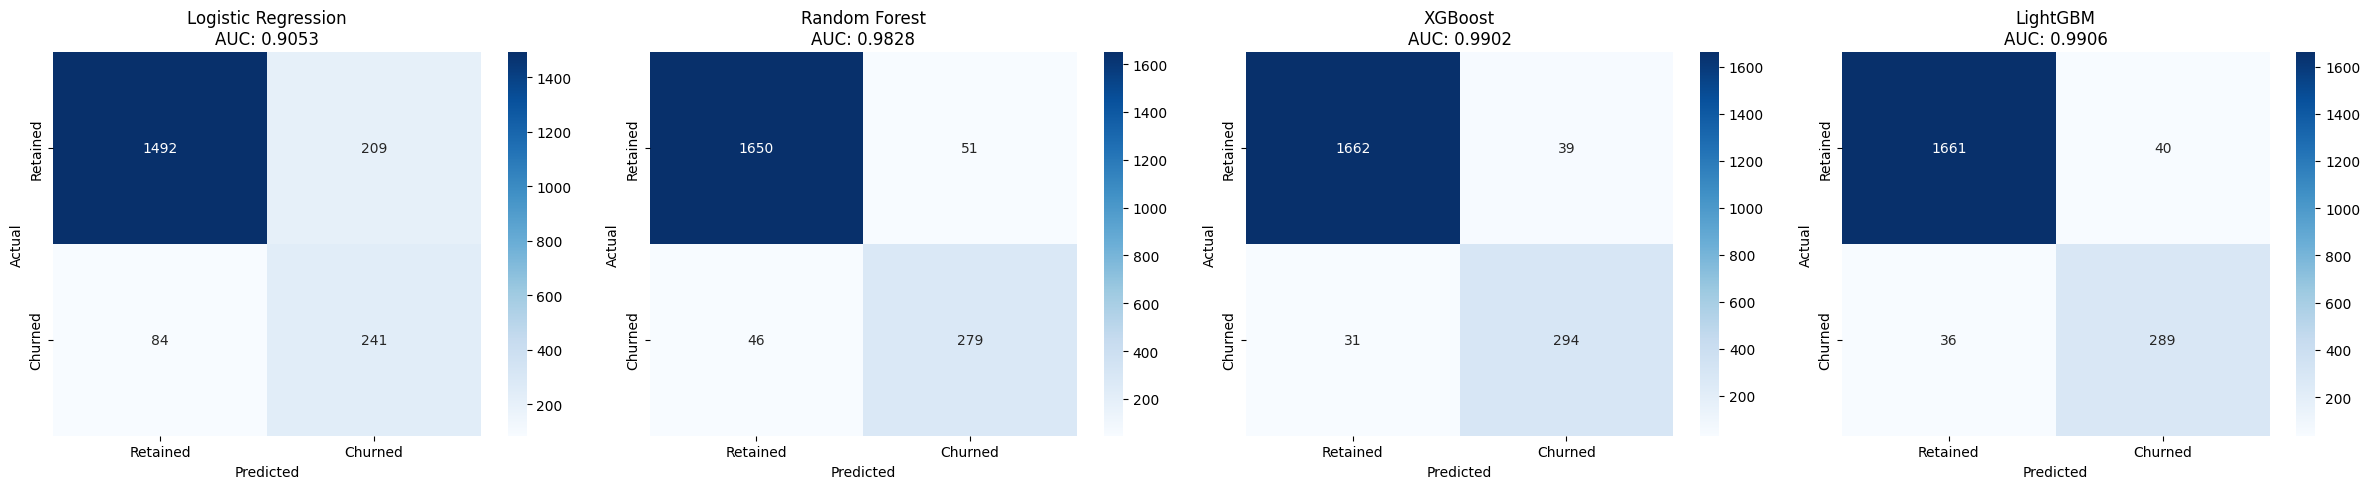

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'])
    ax.set_title(f'{name}\nAUC: {res["auc"]:.4f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

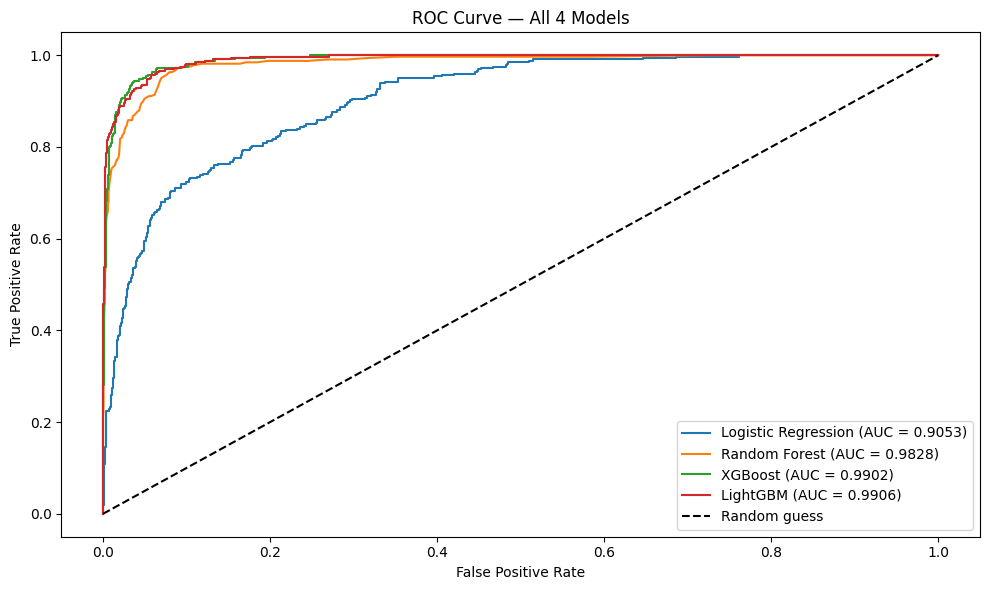

In [29]:
plt.figure(figsize=(10, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All 4 Models')
plt.legend()
plt.tight_layout()
plt.show()

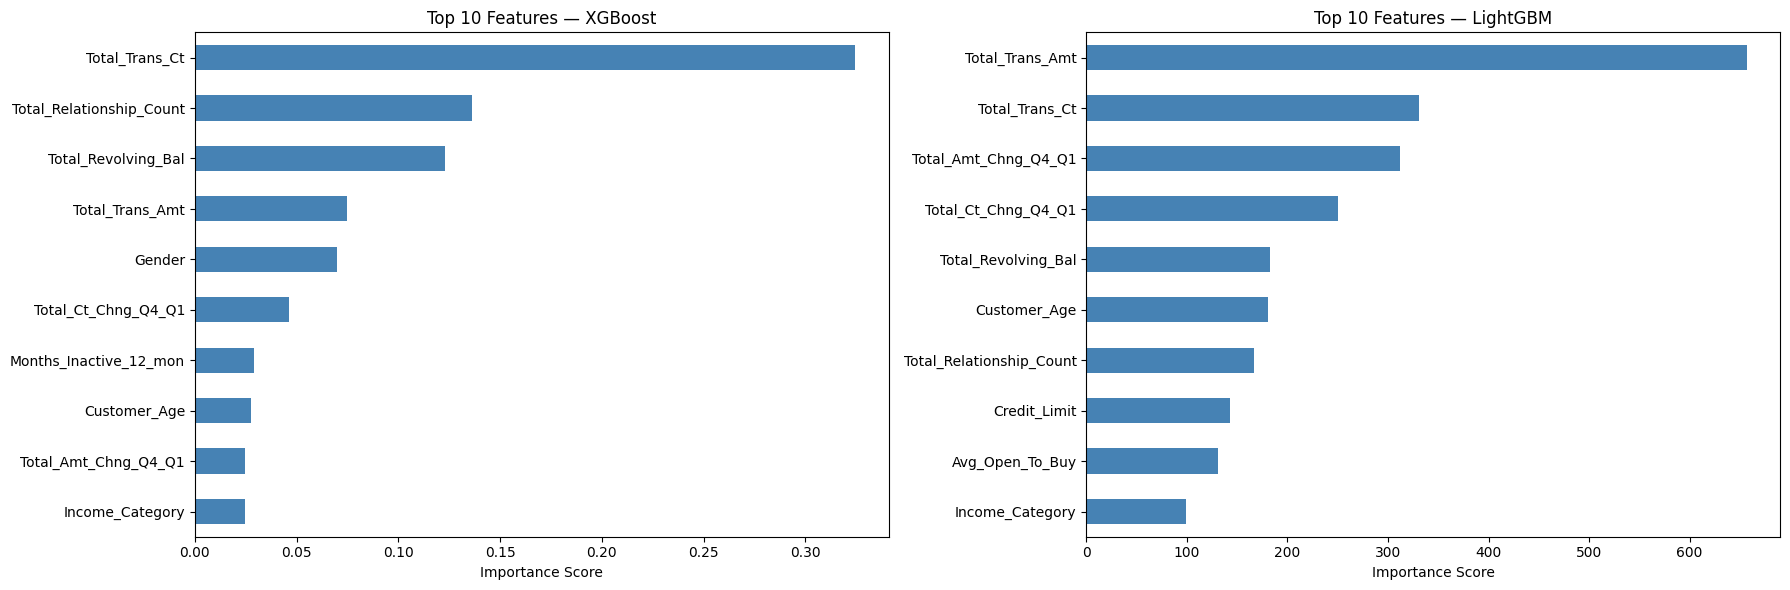

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, model_name in zip(axes, ['XGBoost', 'LightGBM']):
    feat_imp = pd.Series(
        results[model_name]['model'].feature_importances_,
        index=X.columns
    ).sort_values(ascending=False).head(10)

    feat_imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 10 Features — {model_name}')
    ax.set_xlabel('Importance Score')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [31]:
print("\n" + "="*55)
print(f"{'MODEL':<25} {'ACCURACY':>10} {'ROC-AUC':>10}")
print("="*55)
for name, res in results.items():
    print(f"{name:<25} {res['accuracy']:>10.4f} {res['auc']:>10.4f}")
print("="*55)

# Best model
best = max(results, key=lambda x: results[x]['auc'])
print(f"\nBest model by AUC: {best} ({results[best]['auc']:.4f})")


MODEL                       ACCURACY    ROC-AUC
Logistic Regression           0.8554     0.9053
Random Forest                 0.9521     0.9828
XGBoost                       0.9654     0.9902
LightGBM                      0.9625     0.9906

Best model by AUC: LightGBM (0.9906)


## Business Recommendation

### Best Model: LightGBM
ROC-AUC: 0.9906 — correctly separates churners from
retained customers 99% of the time

### Key Churn Drivers (from feature importance)
1. Total_Trans_Ct — transaction frequency is the #1 signal
2. Total_Trans_Amt — how much they spend matters equally
3. Total_Relationship_Count — customers with fewer products churn more
4. Total_Revolving_Bal — low revolving balance = higher risk
5. Total_Amt_Chng_Q4_Q1 — declining spend quarter-over-quarter

### High Risk Customer Profile
A customer is at high churn risk if they:
- Make fewer than 51 transactions in 12 months
- Spend less than $2,772 total
- Hold only 1–2 bank products
- Show declining transaction amount (Q4 vs Q1 ratio < 0.7)

### Recommended Business Actions

1. EARLY WARNING SYSTEM
   Flag customers when Total_Trans_Ct drops below 51
   AND Total_Trans_Amt drops below $2,772
   → Trigger automated retention outreach at this point

2. PRODUCT CROSS-SELL
   Customers with low Total_Relationship_Count churn more
   → Offer savings account or loan product to increase stickiness

3. SPEND INCENTIVE
   Declining Total_Amt_Chng_Q4_Q1 is a warning sign
   → Cashback offer when quarterly spend drops >20%

4. COST-BENEFIT
   Cost of losing 1 customer >> cost of 1 retention offer
   Model catches 99% of churners — retention campaign ROI is high

### Model Recommendation for Deployment
Use LightGBM — fastest inference, best AUC,
handles new customer data efficiently

In [32]:
import pickle

# Save the best model
with open('lightgbm_churn_model.pkl', 'wb') as f:
    pickle.dump(results['LightGBM']['model'], f)

# Save the scaler too — needed to preprocess new data
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved successfully!")
print("Files: lightgbm_churn_model.pkl, scaler.pkl")

Model saved successfully!
Files: lightgbm_churn_model.pkl, scaler.pkl
